<a href="https://colab.research.google.com/github/pranavv2707/oscilloscope/blob/main/dl_autoencoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PRE PROCESSING STAGE
gpu checks, data downloads and getting the paths of the respective audio and noise files and then adding them together into one mixed audio sample

In [2]:
import numpy as np #arrays / basic tensors
import matplotlib.pyplot as plt # plotting comparisons
import tensorflow as tf
from tensorflow.keras import layers, Model #the ac model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU')) #gpu check

2.20.0
GPU: []


In [3]:
# Download a small subset of LibriSpeech (clean speech, ~300MB)
!wget -q https://www.openslr.org/resources/12/dev-clean.tar.gz
!tar -xzf dev-clean.tar.gz
print("LibriSpeech done!")

# Download ESC-50 (environmental noise, ~600MB)
!git clone -q https://github.com/karolpiczak/ESC-50.git
print("ESC-50 done!")

###from claude only, for the data

LibriSpeech done!
ESC-50 done!


In [4]:
import os
#file handling so the file structure is seen
for root, dirs, files in os.walk('LibriSpeech/dev-clean'):
    level = root.replace('LibriSpeech/dev-clean', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:  # only show files 2 levels deep
        for f in files[:3]:
            print(f'  {indent}{f}')
        break

dev-clean/
  6319/
    64726/
      6319-64726-0017.flac
      6319-64726-0011.flac
      6319-64726-0009.flac


In [5]:
!pip install -q librosa
#install jic

Total speech files found: 2703
Sample rate: 16000 Hz
Duration: 6.79 seconds
Shape: (108720,)
Min: -0.356, Max: 0.347


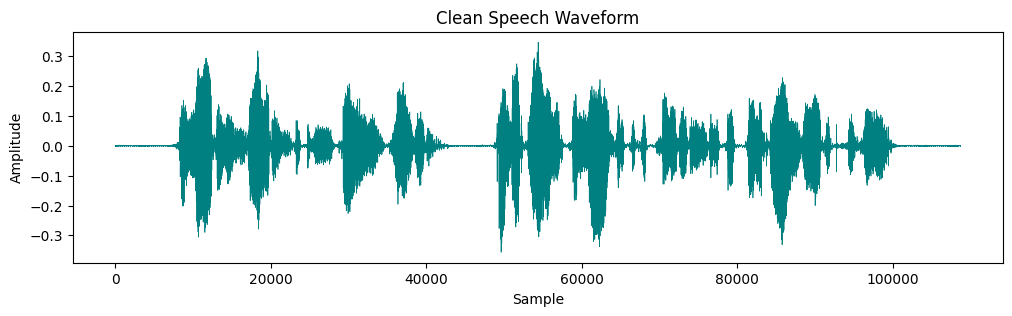

In [6]:
import librosa
import librosa.display #librosa library for all sounds based usecases

speech_files = []
for root, dirs, files in os.walk('LibriSpeech/dev-clean'):
    for f in files:
        if f.endswith('.flac'):
            speech_files.append(os.path.join(root, f))
#get the entire path name of those files which have the ".flac" extension

print(f"Total speech files found: {len(speech_files)}")

clean, sr = librosa.load(speech_files[0], sr=16000) #sample
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(clean)/sr:.2f} seconds")
print(f"Shape: {clean.shape}")
print(f"Min: {clean.min():.3f}, Max: {clean.max():.3f}")

# Plot it
plt.figure(figsize=(12, 3))
plt.plot(clean, color='#008080', lw=0.5)
plt.title('Clean Speech Waveform')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()

Total noise files found: 2000
Noise file: 4-152958-A-18.wav


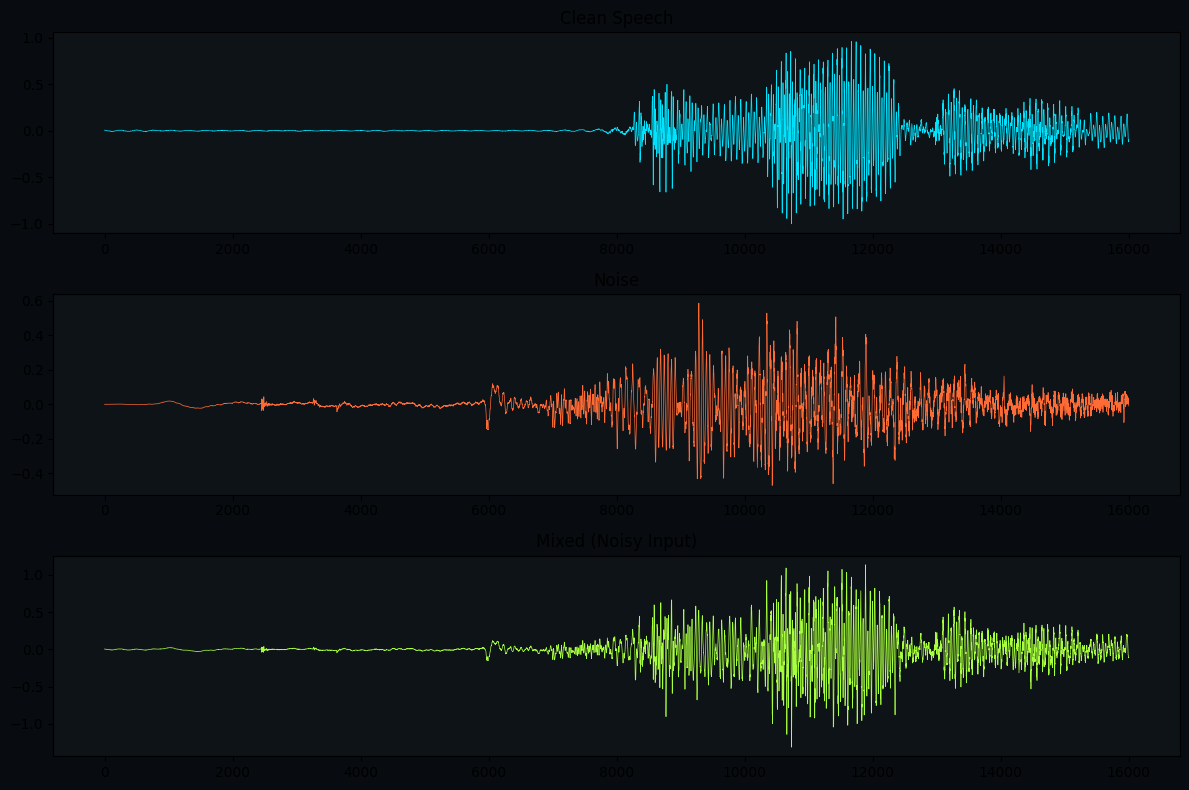

In [7]:

noise_files = []
for root, dirs, files in os.walk('ESC-50/audio'):
    for f in files:
        if f.endswith('.wav'):
            noise_files.append(os.path.join(root, f))

#just like how the initial sound file path was got, get the noise file path for those w the .wav extension

print(f"Total noise files found: {len(noise_files)}")

noise_raw, _ = librosa.load(noise_files[0], sr=16000)
print(f"Noise file: {os.path.basename(noise_files[0])}")

length = 16000
clean_chunk = clean[:length]
noise_chunk = noise_raw[:length] if len(noise_raw) >= length else np.pad(noise_raw, (0, length - len(noise_raw)))
#interpolation with the required smaplign rate to ensure uniformity

clean_chunk /= (np.max(np.abs(clean_chunk)) + 1e-8)
#then normalise bwteeen -1,1

# Add noise at SNR = 5dB
snr_db = 5
noise_power = np.var(clean_chunk) / (10 ** (snr_db / 10))
noise_chunk = np.sqrt(noise_power) * noise_chunk / (np.std(noise_chunk) + 1e-8)
noisy_chunk = clean_chunk + noise_chunk

'''same way as generate pairs : add noise using the SNR formula and the noise-variance relation
and generate anoisy chunk and plot side by side mari
'''
# Plot side by side
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
pairs = [
    (clean_chunk,  '#00e5ff', 'Clean Speech'),  #clean wala chunk
    (noise_chunk,  '#ff6b35', 'Noise'), #the ac noise which is to be added
    (noisy_chunk,  '#a8ff3e', 'Mixed (Noisy Input)'),#final noisy singal
]
for ax, (sig, col, title) in zip(axes, pairs):
    ax.plot(sig, color=col, lw=0.5)
    ax.set_title(title)
    ax.set_facecolor('#0e1318')
fig.patch.set_facecolor('#080c10')
plt.tight_layout()
plt.show()

## DATA  GENERATION
using a random snr, get the noise add to signal and do the same for all the samples

In [8]:
def load_voice_pairs(speech_files, noise_files, n_samples=5000, length=16000):
    X_noisy, y_clean = [], []

    for i in range(n_samples):
        cf = np.random.choice(speech_files)
        clean, _ = librosa.load(cf, sr=16000)

        if len(clean) < length:
            clean = np.pad(clean, (0, length - len(clean))) #zero pad for the correct length
        else:
            # get random starting places so theres more variety of data and then get a 1s sample (length = 16k ensures it)
            start = np.random.randint(0, len(clean) - length)
            clean = clean[start:start + length]

        clean /= (np.max(np.abs(clean)) + 1e-8)

        nf = np.random.choice(noise_files)
        noise, _ = librosa.load(nf, sr=16000)

        if len(noise) < length:
            noise = np.pad(noise, (0, length - len(noise)))
        else:
            start = np.random.randint(0, len(noise) - length)
            noise = noise[start:start + length]

        #do the same exact proocedure for the noise part also

       # now just like the genrate pairs procedure get a random snr, get the noise from the SNR, noise power - variance relation
        snr_db = np.random.uniform(-5, 15)
        noise_power = np.var(clean) / (10 ** (snr_db / 10))
        noise = np.sqrt(noise_power) * noise / (np.std(noise) + 1e-8)

        X_noisy.append(clean + noise)
        y_clean.append(clean)

        #updae print
        if (i + 1) % 500 == 0:
            print(f"{i + 1}/{n_samples} done...")

    return np.array(X_noisy), np.array(y_clean)

In [9]:
print("Building dataset...")
X, y = load_voice_pairs(speech_files, noise_files, n_samples=12000)

# Add channel dimension for Conv1D
X = X[..., np.newaxis]   # (5000, 16000, 1)
y = y[..., np.newaxis]

# Train / test split — 90% train, 10% test
split = int(0.9 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Building dataset...
500/12000 done...
1000/12000 done...
1500/12000 done...
2000/12000 done...
2500/12000 done...
3000/12000 done...
3500/12000 done...
4000/12000 done...
4500/12000 done...
5000/12000 done...
5500/12000 done...
6000/12000 done...
6500/12000 done...
7000/12000 done...
7500/12000 done...
8000/12000 done...
8500/12000 done...
9000/12000 done...
9500/12000 done...
10000/12000 done...
10500/12000 done...
11000/12000 done...
11500/12000 done...
12000/12000 done...
Train: (10800, 16000, 1)
Test:  (1200, 16000, 1)


check the generated data once, for the high SNR and low SNR points

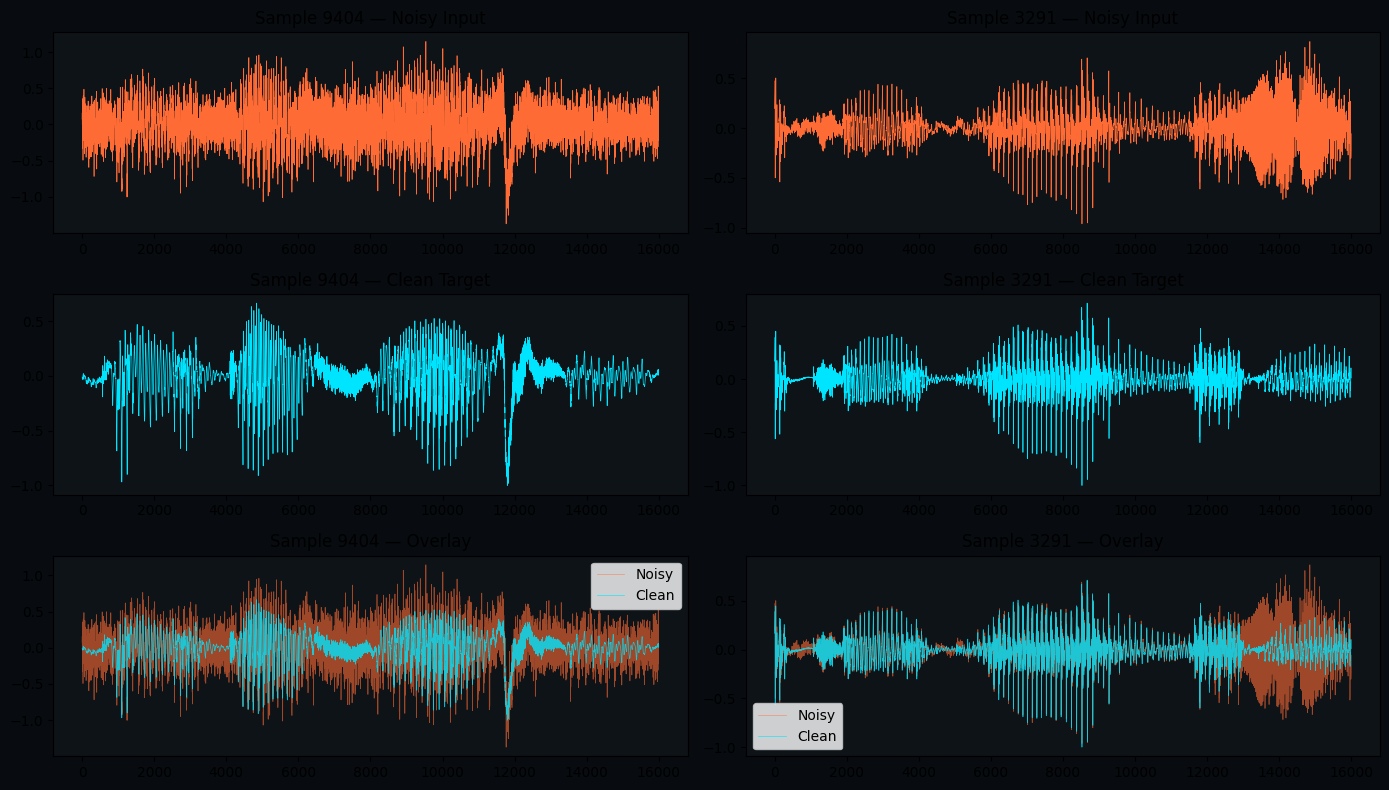

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))

for col in range(2):
    idx = np.random.randint(0, len(X_train))
    noisy = X_train[idx].squeeze()
    clean = y_train[idx].squeeze()

    axes[0][col].plot(noisy, color='#ff6b35', lw=0.5)
    axes[0][col].set_title(f'Sample {idx} — Noisy Input')
    axes[0][col].set_facecolor('#0e1318')

    axes[1][col].plot(clean, color='#00e5ff', lw=0.5)
    axes[1][col].set_title(f'Sample {idx} — Clean Target')
    axes[1][col].set_facecolor('#0e1318')

    axes[2][col].plot(noisy, color='#ff6b35', lw=0.5, alpha=0.6, label='Noisy')
    axes[2][col].plot(clean, color='#00e5ff', lw=0.5, alpha=0.8, label='Clean')
    axes[2][col].set_title(f'Sample {idx} — Overlay')
    axes[2][col].set_facecolor('#0e1318')
    axes[2][col].legend()

fig.patch.set_facecolor('#080c10')
plt.tight_layout()
plt.show()

#take 2 samples, and then see the noise, clean audio and then the overlay; check if the SNR is high or not

## THE TENSORFLOW MODEL





In [11]:
#actual model
from tensorflow.keras import layers, Model

def build_autoencoder(input_length=16000):
    inputs = layers.Input(shape=(input_length, 1))


# Conv1D arguments (filters, kernel_size, padding, activation)
# filters       - how many different filters to learn simultaneously
# kernel_size- how many samples each filter looks at at once
# padding=same- keeps signal length unchanged after convolution
# relu- if output is negative make it zero
# naxpooling - halves the length by keeping max of every 2 samples (same as kinect depoth sensor proejct)


    x = layers.Conv1D(16, 9, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling1D(2)(x)           # 16000 → 8000

    x = layers.Conv1D(32, 9, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)           # 8000 → 4000

    x = layers.Conv1D(64, 9, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)           # 4000 → 2000

    x = layers.Conv1D(128, 9, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)           # 2000 → 1000

    x = layers.Conv1D(256, 9, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)           # 1000 → 500 ← deeper bottleneck
  # bottleneck: signal compressed to 500 numbers
  #speech has structure (phonemes, rhythm, pitch) so it compresses well and survives
  #noise is random so it compresses poorly and gets squeezed out here

    #(the dataset is now compressed to just 0.5k no.s since speech has pattern its compressed well and since noise is random it gets compressed poorly,
    #so on expanding now there is sure chance that the noise doesnt survive and the well compressed speech is kept intact)

    x = layers.Conv1DTranspose(256, 9, padding='same', activation='relu')(x)
    x = layers.UpSampling1D(2)(x)           # 500 → 1000

    x = layers.Conv1DTranspose(128, 9, padding='same', activation='relu')(x)
    x = layers.UpSampling1D(2)(x)           # 1000 → 2000

    x = layers.Conv1DTranspose(64, 9, padding='same', activation='relu')(x)
    x = layers.UpSampling1D(2)(x)           # 2000 → 4000

    x = layers.Conv1DTranspose(32, 9, padding='same', activation='relu')(x)
    x = layers.UpSampling1D(2)(x)           # 4000 → 8000

    x = layers.Conv1DTranspose(16, 9, padding='same', activation='relu')(x)
    x = layers.UpSampling1D(2)(x)           # 8000 → 16000

    # ---- OUTPUT ----
    # 1 filter since output is mono audio (1 channel)
    # tanh used instead of relu because audio is bipolar (goes + and -)
    # tanh output range is [-1, 1] which matches our normalized audio perfectly
    # relu would kill all negative audio values and sound terrible

#skip conneection to reduce the decrease in SNR first observed
    # instead of learning "what clean sounds like" (hard),
  # model learns "what noise to subtract" (easier)
  # decoded = the correction to apply, inputs = original signal
  # final output = original + correction
    decoded = layers.Conv1D(1, kernel_size=9, padding='same', activation='tanh')(x)
    outputs = layers.Add()([inputs, decoded])

    return Model(inputs, outputs, name='voice_denoiser_v3')

model = build_autoencoder(input_length=16000)
model.summary()



Model: "voice_denoiser_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 16000, 16) │        160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 8000, 16)  │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 8000, 32)  │      4,640 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 4000, 32)  │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 4000, 64)  │     18,496 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 2000, 64)  │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2000, 128) │     73,856 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 1000, 128) │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1000, 256) │    295,168 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 500, 256)  │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose    │ (None, 500, 256)  │    590,080 │ max_pooling1d_4[… │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d       │ (None, 1000, 256) │          0 │ conv1d_transpose… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose_1  │ (None, 1000, 128) │    295,040 │ up_sampling1d[0]… │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_1     │ (None, 2000, 128) │          0 │ conv1d_transpose… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose_2  │ (None, 2000, 64)  │     73,792 │ up_sampling1d_1[… │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_2     │ (None, 4000, 64)  │          0 │ conv1d_transpose… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose_3  │ (None, 4000, 32)  │     18,464 │ up_sampling1d_2[… │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,374,465 (5.24 MB)

 Trainable params: 1,374,465 (5.24 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
test_input = X_train[:1]
test_output = model.predict(test_input, verbose=0)

print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Output range: {test_output.min():.3f} to {test_output.max():.3f}")

Input shape:  (1, 16000, 1)
Output shape: (1, 16000, 1)
Output range: -1.069 to 0.997


## TRAINING PHASE
train for 50 epochs

In [13]:
def spectral_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))


    true_stft = tf.abs(tf.signal.stft(
        tf.squeeze(y_true, -1), frame_length=256, frame_step=64))
    pred_stft = tf.abs(tf.signal.stft(
        tf.squeeze(y_pred, -1), frame_length=256, frame_step=64))
    freq_loss = tf.reduce_mean(tf.square(true_stft - pred_stft))

    return 0.5 * mse + 0.5 * freq_loss

In [ ]:
# rebuild fresh weights first
model = build_autoencoder(input_length=16000)

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss=spectral_loss
)

# updated callbacks — more patient this time
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=8, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/100
 90/304 ━━━━━━━━━━━━━━━━━━━━ 23:55 7s/step - loss: 0.7575

In [ ]:

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], color='#00e5ff', label='Train Loss')
plt.plot(history.history['val_loss'], color='#ff6b35', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.facecolor = '#080c10'
plt.show()


idx = np.random.randint(0, len(X_test))
noisy  = X_test[idx].squeeze()
clean  = y_test[idx].squeeze()
output = model.predict(X_test[idx:idx+1], verbose=0)[0].squeeze()

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
pairs = [
    (noisy,          '#ff6b35', 'Noisy Input'),
    (output,         '#00e5ff', 'Model Output'),
    (clean,          '#a8ff3e', 'Clean Target'),
    (output - clean, '#c77dff', 'Residual Error (Output - Clean)'),
]
for ax, (sig, col, title) in zip(axes, pairs):
    ax.plot(sig, color=col, lw=0.6)
    ax.set_title(title, color='#c8d8e8')
    ax.set_facecolor('#0e1318')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2530')
fig.patch.set_facecolor('#080c10')
plt.tight_layout()
plt.show()

snr_improvements = []
snr_before_all   = []
snr_after_all    = []

print("Computing SNR across test set...")
for i in range(len(X_test)):
    n = X_test[i].squeeze()
    c = y_test[i].squeeze()
    o = model.predict(X_test[i:i+1], verbose=0)[0].squeeze()

    before = 10 * np.log10(np.var(c) / (np.var(n - c) + 1e-10))
    after  = 10 * np.log10(np.var(c) / (np.var(o - c) + 1e-10))

    snr_before_all.append(before)
    snr_after_all.append(after)
    snr_improvements.append(after - before)

print(f"\nAverage SNR before: {np.mean(snr_before_all):.2f} dB")
print(f"Average SNR after:  {np.mean(snr_after_all):.2f} dB")
print(f"Average improvement: {np.mean(snr_improvements):.2f} dB")


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(snr_before_all, bins=30, color='#ff6b35', alpha=0.7, label='Before')
axes[0].hist(snr_after_all,  bins=30, color='#00e5ff', alpha=0.7, label='After')
axes[0].set_title('SNR Distribution Before vs After', color='#c8d8e8')
axes[0].set_xlabel('SNR (dB)')
axes[0].set_facecolor('#0e1318')
axes[0].legend()

axes[1].hist(snr_improvements, bins=30, color='#a8ff3e', alpha=0.8)
axes[1].set_title('SNR Improvement per Sample', color='#c8d8e8')
axes[1].set_xlabel('Improvement (dB)')
axes[1].set_facecolor('#0e1318')
axes[1].axvline(x=0, color='#ff6b35', linestyle='--', label='Zero improvement')
axes[1].axvline(x=np.mean(snr_improvements), color='#00e5ff',
                linestyle='--', label=f'Mean: {np.mean(snr_improvements):.1f} dB')
axes[1].legend()

fig.patch.set_facecolor('#080c10')
plt.tight_layout()
plt.show()

from IPython.display import Audio, display

print("Noisy input:")
display(Audio(noisy, rate=16000))

print("Model output:")
display(Audio(output, rate=16000))

print("Clean target:")
display(Audio(clean, rate=16000))

In [1]:
model.save('denoiser_v3_epoch51.h5')
from google.colab import files
files.download('denoiser_v3_epoch51.h5')

NameError: name 'model' is not defined